In [1]:
import numpy as np
import pandas as pd

In [2]:
eve=pd.read_csv('athlete_events.csv')
reg=pd.read_csv('noc_regions.csv')

In [3]:
eve.tail()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN
271115,135571,Tomasz Ireneusz ya,M,34.0,185.0,96.0,Poland,POL,2002 Winter,2002,Winter,Salt Lake City,Bobsleigh,Bobsleigh Men's Four,NaN


In [4]:
eve.shape

(271116, 15)

In [5]:
eve=eve[eve['Season']=='Summer']

In [6]:
eve.shape

(222552, 15)

In [7]:
reg.tail()

,NOC,region,notes
225,YEM,Yemen,NaN
226,YMD,Yemen,South Yemen
227,YUG,Serbia,Yugoslavia
228,ZAM,Zambia,NaN
229,ZIM,Zimbabwe,NaN


In [8]:
eve=eve.merge(reg,on='NOC',how='left')

In [9]:
eve['region'].unique().shape

(206,)

In [10]:
eve.isna().sum()

ID             0
Name           0
Sex            0
Age         9189
Height     51857
Weight     53854
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     188464
region       370
notes     218151
dtype: int64

In [11]:
eve.duplicated().sum()

np.int64(1385)

In [12]:
eve.drop_duplicates(inplace=True)

In [13]:
eve=pd.concat([eve,pd.get_dummies(eve['Medal'],dtype=int)],axis=1)

In [14]:
eve.groupby('NOC').sum()[['Gold','Silver','Bronze']].sort_values('Gold',ascending=False).reset_index()

,NOC,Gold,Silver,Bronze
0,USA,2472,1333,1197
1,URS,832,635,596
2,GBR,635,729,620
3,GER,592,538,649
4,ITA,518,474,454
...,...,...,...,...
225,AHO,0,1,0
226,LBR,0,0,0
227,LCA,0,0,0
228,LES,0,0,0


In [15]:
eve[(eve['NOC']=='IND')&(eve['Medal']=='Gold')]

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
4186,2699,Shaukat Ali,M,30.0,NaN,NaN,India,IND,1928 Summer,1928,Summer,Amsterdam,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0
4190,2703,Syed Mushtaq Ali,M,22.0,165.0,61.0,India,IND,1964 Summer,1964,Summer,Tokyo,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0
4460,2864,Richard James Allen,M,25.0,172.0,NaN,India,IND,1928 Summer,1928,Summer,Amsterdam,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0
4461,2864,Richard James Allen,M,30.0,172.0,NaN,India,IND,1932 Summer,1932,Summer,Los Angeles,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0
4462,2864,Richard James Allen,M,34.0,172.0,NaN,India,IND,1936 Summer,1936,Summer,Berlin,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191759,117232,Dung Dung Sylvanus,M,31.0,160.0,62.0,India,IND,1980 Summer,1980,Summer,Moskva,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0
193964,118553,Carlyle Carrol Tapsell,M,23.0,182.0,NaN,India,IND,1932 Summer,1932,Summer,Los Angeles,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0
193965,118553,Carlyle Carrol Tapsell,M,27.0,182.0,NaN,India,IND,1936 Summer,1936,Summer,Berlin,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0
205949,125560,"Max ""Maxie"" Vaz",M,NaN,NaN,NaN,India,IND,1948 Summer,1948,Summer,London,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0


In [16]:
medalTally=eve.drop_duplicates(subset=['Team','NOC','Games','Year','City','Sport','Event','Medal'])

In [17]:
medalTally=medalTally.groupby('region').sum()[['Gold','Silver','Bronze']].sort_values('Gold',ascending=False).reset_index()

In [18]:
medalTally['total']=medalTally['Gold']+medalTally['Silver']+medalTally['Bronze']

In [19]:
medalTally

,region,Gold,Silver,Bronze,total
0,USA,1035,802,708,2545
1,Russia,592,498,487,1577
2,Germany,444,457,491,1392
3,UK,278,317,300,895
4,France,234,256,287,777
...,...,...,...,...,...
200,Lesotho,0,0,0,0
201,Albania,0,0,0,0
202,Libya,0,0,0,0
203,Liechtenstein,0,0,0,0


In [20]:
yrs=eve['Year'].unique().tolist()
yrs

[1992,
 2012,
 1920,
 1900,
 1932,
 1952,
 2000,
 1996,
 1912,
 1924,
 1948,
 2008,
 2016,
 2004,
 1984,
 1968,
 1972,
 1988,
 1936,
 1956,
 1960,
 1928,
 1976,
 1980,
 1964,
 1906,
 1904,
 1908,
 1896]

In [21]:
yrs.sort()
yrs

[1896,
 1900,
 1904,
 1906,
 1908,
 1912,
 1920,
 1924,
 1928,
 1932,
 1936,
 1948,
 1952,
 1956,
 1960,
 1964,
 1968,
 1972,
 1976,
 1980,
 1984,
 1988,
 1992,
 1996,
 2000,
 2004,
 2008,
 2012,
 2016]

In [22]:
yrs.insert(0,'Overall')

In [23]:
country=np.unique(eve['region'].dropna().values).tolist()

In [24]:
country.sort()
# country

In [25]:
country.insert(0,'Overall')

In [26]:
def get_medalTally(eve,yr,country):
    medalDf=eve.drop_duplicates(subset=['Team','NOC','Games','Year','City','Sport','Event','Medal'])
    f=0
    if yr=='Overall' and country=='Overall':
        temp=medalDf
    if yr=='Overall' and country!='Overall':
        f=1
        temp=medalDf[medalDf['region']==country]
    if yr!='Overall' and country=='Overall':
        temp=medalDf[medalDf['Year']==int(yr)]
    if yr!='Overall' and country!='Overall':
        temp=medalDf[(medalDf['Year']==int(yr)) & (medalDf['region']==country)]

    if f==1:
        x=temp.groupby('Year').sum()[['Gold','Silver','Bronze']].sort_values('Year').reset_index()
    else:
        x=temp.groupby('region').sum()[['Gold','Silver','Bronze']].sort_values('Gold',ascending=False).reset_index()
    x['total']=x['Gold']+x['Silver']+x['Bronze']
    print(x)
    

In [27]:
get_medalTally(yr='Overall',country='Overall')

TypeError: get_medalTally() missing 1 required positional argument: 'eve'

In [ ]:
get_medalTally(yr='1900',country='India')

In [ ]:
get_medalTally(yr='2016',country='France')

In [29]:
eve['Year'].unique().shape[0]-1

28

In [30]:
eve['City'].unique()

array(['Barcelona', 'London', 'Antwerpen', 'Paris', 'Los Angeles',
       'Helsinki', 'Sydney', 'Atlanta', 'Stockholm', 'Beijing',
       'Rio de Janeiro', 'Athina', 'Mexico City', 'Munich', 'Seoul',
       'Berlin', 'Melbourne', 'Roma', 'Amsterdam', 'Montreal', 'Moskva',
       'Tokyo', 'St. Louis'], dtype=object)

In [31]:
eve['Sport'].unique().shape

(52,)

In [32]:
eve['Event'].unique().shape[0]

651

In [33]:
eve['Name'].unique().shape[0]

116122

In [34]:
eve['region'].unique().shape[0]

206

In [35]:
nations_over_time=eve.drop_duplicates(['Year','region'])['Year'].value_counts().reset_index().sort_values('Year')
nations_over_time.rename(columns={'Year':'Edtions','count':'No of Countries'},inplace=True)

In [36]:
import plotly.express as px
fig=px.line(nations_over_time,x='Edtions',y='No of Countries')
fig.show()

In [37]:
eve.drop_duplicates(['Year','Event'])['Year'].value_counts().reset_index().sort_values('Year')

,Year,count
28,1896,43
26,1900,90
25,1904,95
27,1906,74
23,1908,109
24,1912,107
14,1920,158
20,1924,131
22,1928,122
21,1932,131


In [38]:
x=eve.drop_duplicates(['Year','Sport','Event'])

<Axes: xlabel='Year', ylabel='Sport'>

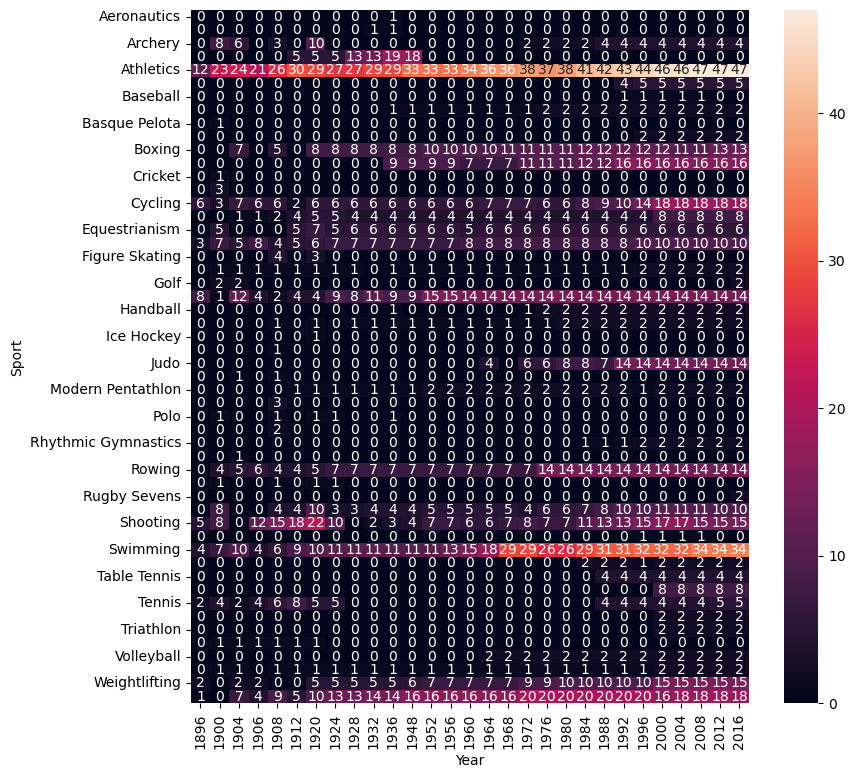

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(9,9))
sns.heatmap(x.pivot_table(index='Sport',columns='Year',values='Event',aggfunc='count').fillna(0).astype(int),annot=True)

In [40]:
def most_successful(eve,sport):
    temp=eve.dropna(subset=['Medal'])
    if sport!='Overall':
        temp=temp[temp['Sport']==sport]
    x=temp['Name'].value_counts().reset_index().head(15).merge(eve,on='Name',how='left')[['Name','count','Sport','region']].drop_duplicates('Name')
    x.rename(columns={'count':'Medals'},inplace=True)
    return x

In [41]:
most_successful(eve,'Overall')

,Name,Medals,Sport,region
0,"Michael Fred Phelps, II",28,Swimming,USA
30,Larysa Semenivna Latynina (Diriy-),18,Gymnastics,Russia
49,Nikolay Yefimovich Andrianov,15,Gymnastics,Russia
73,Borys Anfiyanovych Shakhlin,13,Gymnastics,Russia
97,Takashi Ono,13,Gymnastics,Japan
130,Edoardo Mangiarotti,13,Fencing,Italy
144,"Dara Grace Torres (-Hoffman, -Minas)",12,Swimming,USA
157,Aleksey Yuryevich Nemov,12,Gymnastics,Russia
178,"Jennifer Elisabeth ""Jenny"" Thompson (-Cumpelik)",12,Swimming,USA
195,Birgit Fischer-Schmidt,12,Canoeing,Germany


In [42]:
temp=eve.dropna(subset=['Medal'])

In [43]:
temp.drop_duplicates(subset=['Team','NOC','Games','Year','City','Sport','Event','Medal'],inplace=True)

C:\Users\manas\AppData\Local\Temp\ipykernel_5436\1023283187.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [44]:
new=temp[temp['region']=='India']
final=new.groupby('Year').count()['Medal'].reset_index()

In [45]:
fig=px.line(final,x='Year',y='Medal')
fig.show()

<Axes: xlabel='Year', ylabel='Sport'>

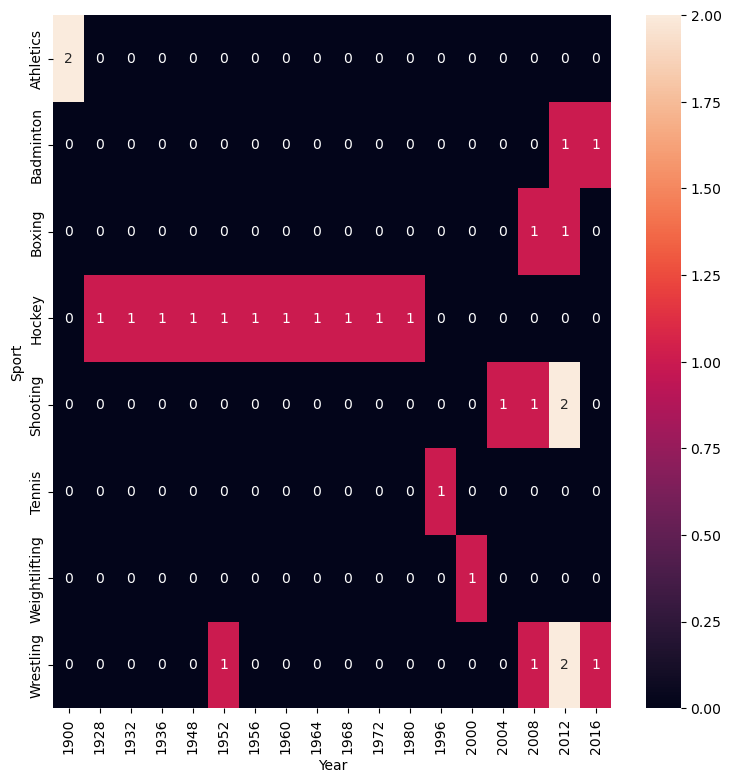

In [46]:
new=temp[temp['region']=='India']
plt.figure(figsize=(9,9))
sns.heatmap(new.pivot_table(index='Sport',columns='Year',values='Medal',aggfunc='count').fillna(0).astype(int),annot=True)

In [47]:
def most_successful(eve,country):
    temp=eve.dropna(subset=['Medal'])
    temp=temp[temp['region']==country]
    x=temp['Name'].value_counts().reset_index().head(15).merge(eve,on='Name',how='left')[['Name','count','Sport']].drop_duplicates('Name')
    x.rename(columns={'count':'Medals'},inplace=True)
    return x

In [48]:
most_successful(eve,'USA')

,Name,Medals,Sport
0,"Michael Fred Phelps, II",28,Swimming
30,Ryan Steven Lochte,12,Swimming
44,"Jennifer Elisabeth ""Jenny"" Thompson (-Cumpelik)",12,Swimming
61,Natalie Anne Coughlin (-Hall),12,Swimming
73,"Dara Grace Torres (-Hoffman, -Minas)",12,Swimming
86,"Matthew Nicholas ""Matt"" Biondi",11,Swimming
98,Carl Townsend Osburn,11,Shooting
114,Mark Andrew Spitz,11,Swimming
126,"Raymond Clarence ""Ray"" Ewry",10,Athletics
136,"Frederick Carlton ""Carl"" Lewis",10,Athletics


In [49]:
import plotly.figure_factory as ff

In [50]:
athlete=eve.dropna(subset=['Name','region'])

In [51]:
x1=athlete['Age'].dropna()
x2=athlete[athlete['Medal']=='Gold']['Age'].dropna()
x3=athlete[athlete['Medal']=='Silver']['Age'].dropna()
x4=athlete[athlete['Medal']=='Bronze']['Age'].dropna()

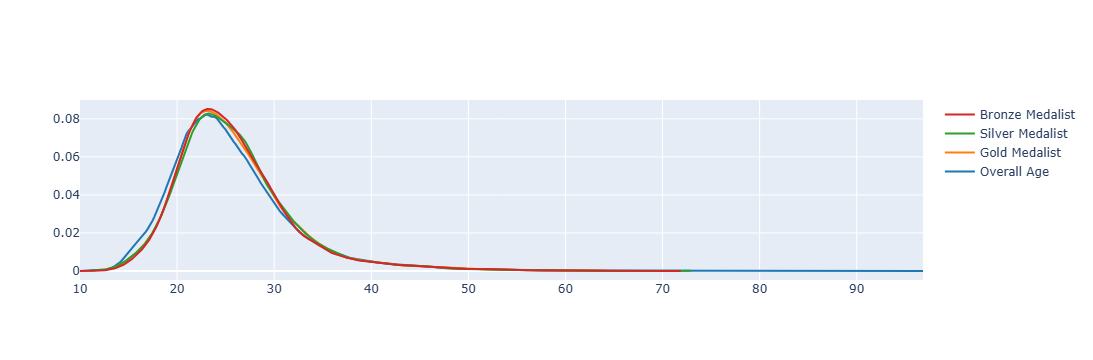

In [52]:
fig=ff.create_distplot([x1,x2,x3,x4],['Overall Age','Gold Medalist','Silver Medalist','Bronze Medalist'],show_hist=False,show_rug=False)
fig.show()

In [53]:
famous_sports = ['Basketball', 'Judo', 'Football', 'Tug-Of-War', 'Athletics',
                 'Swimming', 'Badminton', 'Sailing', 'Gymnastics',
                 'Art Competitions', 'Handball', 'Weightlifting', 'Wrestling',
                 'Water Polo', 'Hockey', 'Rowing', 'Fencing',
                 'Shooting', 'Boxing', 'Taekwondo', 'Cycling', 'Diving', 'Canoeing',
                 'Tennis', 'Golf', 'Softball', 'Archery',
                 'Volleyball', 'Synchronized Swimming', 'Table Tennis', 'Baseball',
                 'Rhythmic Gymnastics', 'Rugby Sevens',
                 'Beach Volleyball', 'Triathlon', 'Rugby', 'Polo', 'Ice Hockey']

In [54]:
x=[]
name=[]
for spr in famous_sports:
    temp=athlete[athlete['Sport']==spr]
    x.append(temp[temp['Medal']=='Gold']['Age'].dropna())
    name.append(spr)

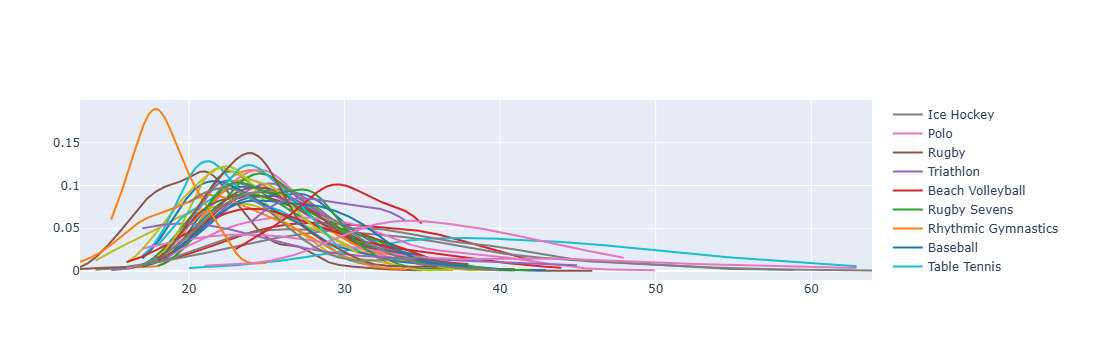

In [55]:
fig=ff.create_distplot(x,name,show_hist=False,show_rug=False)
fig.show()

In [56]:
athlete['Medal'].fillna('No Medal',inplace=True)

C:\Users\manas\AppData\Local\Temp\ipykernel_5436\2138767737.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





<Axes: xlabel='Weight', ylabel='Height'>

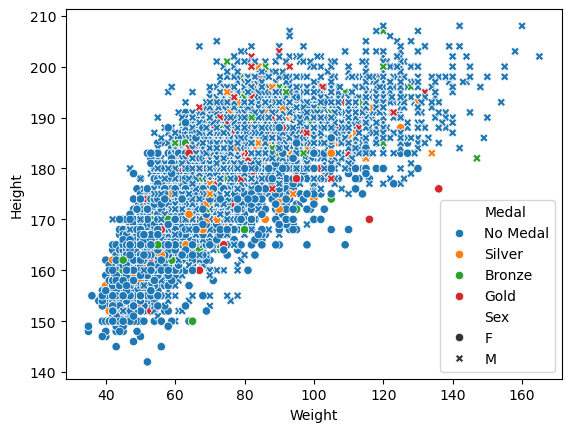

In [57]:
# plt.figure(figsize=(10, 8))
temmp=athlete[athlete['Sport']=='Athletics']
sns.scatterplot(x=temmp['Weight'],y=temmp['Height'],hue=temmp['Medal'],style=temmp['Sex'])

In [59]:
m=athlete[athlete['Sex']=='M'].groupby('Year').count()['Name'].reset_index()
w=athlete[athlete['Sex']=='F'].groupby('Year').count()['Name'].reset_index()

In [61]:
f=m.merge(w,on='Year')
f.rename(columns={'Name_x':'Male','Name_y':'Female'},inplace=True)

In [63]:
f.fillna(0,inplace=True)

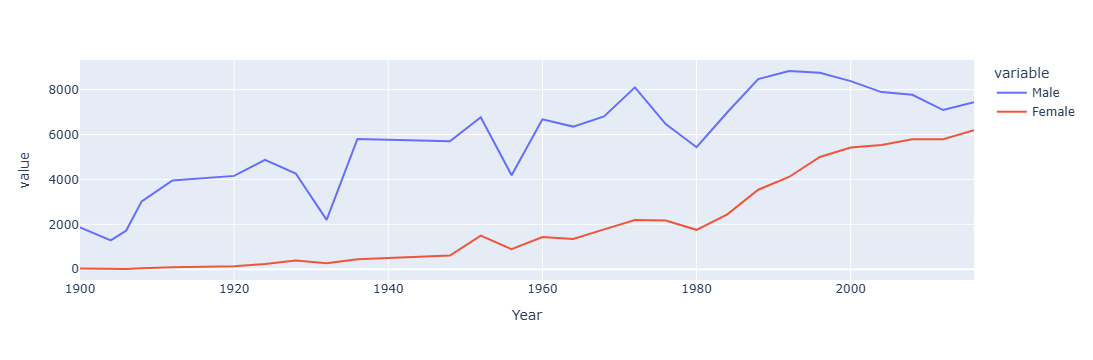

In [64]:
fig=px.line(f,x='Year',y=['Male','Female'])
fig.show()